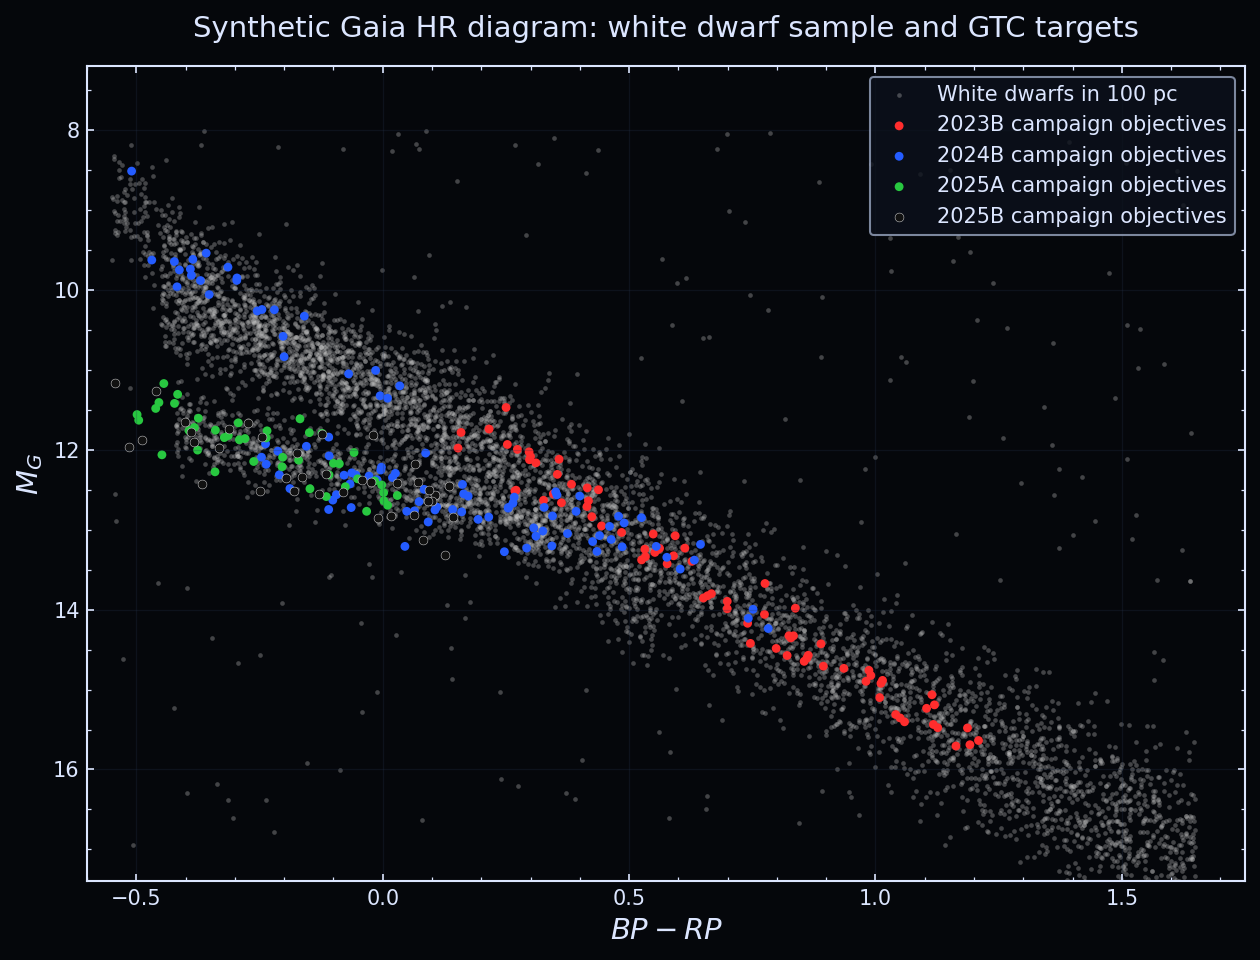

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Synthetic Gaia HR diagram for white dwarfs
# Similar in spirit to Fig. 1 from the paper
# ============================================================

rng = np.random.default_rng(42)

BG = "#05070b"
FG = "#dce6ff"
GRID = "#26364f"

# ------------------------------------------------------------
# 1. Simulate background Gaia 100 pc white dwarf sample
# ------------------------------------------------------------

n_main = 4200

bp_rp_main = rng.uniform(-0.45, 1.65, n_main)

# Main white dwarf cooling sequence:
# brighter/hotter at blue colors, fainter/cooler at red colors
mg_main = (
    10.2
    + 3.3 * (bp_rp_main + 0.45)
    - 0.55 * np.exp(-((bp_rp_main - 0.15) / 0.45) ** 2)
)

mg_main += rng.normal(0, 0.28, n_main)

# broaden lower/faint end
mg_main += rng.normal(0, 0.25 + 0.18 * np.clip(bp_rp_main, 0, None), n_main)

# B branch / upper hot sequence
n_b = 1200
bp_rp_b = rng.uniform(-0.55, 0.55, n_b)
mg_b = 8.9 + 4.6 * (bp_rp_b + 0.55)
mg_b += rng.normal(0, 0.35, n_b)

# Q branch / massive crystallizing white dwarfs
n_q = 900
bp_rp_q = rng.uniform(-0.42, 0.35, n_q)
mg_q = 11.7 + 1.75 * (bp_rp_q + 0.42)
mg_q += rng.normal(0, 0.22, n_q)

# Sparse outliers
n_out = 220
bp_rp_out = rng.uniform(-0.55, 1.65, n_out)
mg_out = rng.uniform(8.0, 17.0, n_out)

bp_rp_bg = np.concatenate([bp_rp_main, bp_rp_b, bp_rp_q, bp_rp_out])
mg_bg = np.concatenate([mg_main, mg_b, mg_q, mg_out])

# ------------------------------------------------------------
# 2. Simulate observed GTC campaign targets
# ------------------------------------------------------------

def sample_from_branch(n, branch="main", color_range=(-0.3, 1.2), jitter=0.12):
    x = rng.uniform(color_range[0], color_range[1], n)

    if branch == "main":
        y = 10.2 + 3.3 * (x + 0.45) - 0.55 * np.exp(-((x - 0.15) / 0.45) ** 2)
    elif branch == "b":
        y = 8.9 + 4.6 * (x + 0.55)
    elif branch == "q":
        y = 11.7 + 1.75 * (x + 0.42)
    else:
        raise ValueError("branch must be: main, b, q")

    y += rng.normal(0, jitter, n)
    return x, y


# 2023B: more ordinary DZ/DQ-like targets along the main cooling track
x_2023, y_2023 = sample_from_branch(
    76,
    branch="main",
    color_range=(0.15, 1.25),
    jitter=0.20,
)

# 2024B: mixed targets, B/Q region and some main-sequence objects
x_2024a, y_2024a = sample_from_branch(55, "q", (-0.25, 0.45), 0.22)
x_2024b, y_2024b = sample_from_branch(25, "b", (-0.55, 0.05), 0.28)
x_2024c, y_2024c = sample_from_branch(18, "main", (0.2, 0.85), 0.22)

x_2024 = np.concatenate([x_2024a, x_2024b, x_2024c])
y_2024 = np.concatenate([y_2024a, y_2024b, y_2024c])

# 2025A: mostly massive DB candidates around Q branch
x_2025a, y_2025a = sample_from_branch(
    43,
    branch="q",
    color_range=(-0.50, 0.05),
    jitter=0.25,
)

# 2025B: same region, slightly broader
x_2025b, y_2025b = sample_from_branch(
    38,
    branch="q",
    color_range=(-0.55, 0.15),
    jitter=0.28,
)

# ------------------------------------------------------------
# 3. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 6.5), dpi=150)

fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.scatter(
    bp_rp_bg,
    mg_bg,
    s=5,
    c="#c7c7c7",
    alpha=0.32,
    linewidths=0,
    label="White dwarfs in 100 pc",
)

ax.scatter(
    x_2023,
    y_2023,
    s=18,
    c="#ff2d2d",
    edgecolors="none",
    label="2023B campaign objectives",
)

ax.scatter(
    x_2024,
    y_2024,
    s=18,
    c="#245cff",
    edgecolors="none",
    label="2024B campaign objectives",
)

ax.scatter(
    x_2025a,
    y_2025a,
    s=18,
    c="#28c840",
    edgecolors="none",
    label="2025A campaign objectives",
)

ax.scatter(
    x_2025b,
    y_2025b,
    s=18,
    c="#111111",
    edgecolors="#d0d0d0",
    linewidths=0.25,
    label="2025B campaign objectives",
)

# Gaia HR diagrams convention: brighter objects at the top
ax.invert_yaxis()

ax.set_xlim(-0.6, 1.75)
ax.set_ylim(17.4, 7.2)

ax.set_xlabel(r"$BP - RP$", color=FG, fontsize=14)
ax.set_ylabel(r"$M_G$", color=FG, fontsize=14)

ax.tick_params(colors=FG, which="both", direction="in", top=True, right=True)
ax.minorticks_on()

for spine in ax.spines.values():
    spine.set_color(FG)
    spine.set_linewidth(1.0)

ax.grid(True, color=GRID, alpha=0.25, linewidth=0.6)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=10,
    facecolor="#0c111c",
    edgecolor="#9aa7c2",
    labelcolor=FG,
)

for text in legend.get_texts():
    text.set_color(FG)

ax.set_title(
    "Synthetic Gaia HR diagram: white dwarf sample and GTC targets",
    color=FG,
    fontsize=14,
    pad=14,
)

plt.tight_layout()
plt.show()

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter

# ============================================================
# Animated synthetic Gaia HR diagram for white dwarfs
# Dark theme, density dip, 4-second final hold
# ============================================================

rng = np.random.default_rng(42)

# =========================================================
# CONFIG
# =========================================================

OUTPUT_FORMAT = "mp4"   # "gif" or "mp4"

OUT_DIR = Path("animations")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FILE = OUT_DIR / f"gaia_white_dwarfs_synthetic.{OUTPUT_FORMAT}"

FPS = 24
DURATION_SEC = 12
HOLD_LAST_SEC = 4
DPI = 140

ANIM_FRAMES = FPS * DURATION_SEC
HOLD_FRAMES = FPS * HOLD_LAST_SEC
TOTAL_FRAMES = ANIM_FRAMES + HOLD_FRAMES

BG = "#05070b"
FG = "#dce6ff"
GRID = "#26364f"

# ------------------------------------------------------------
# Synthetic Gaia 100 pc white dwarf sample
# ------------------------------------------------------------

n_main = 5200
bp_rp_main = rng.uniform(-0.45, 1.65, n_main)

mg_main = (
    10.2
    + 3.3 * (bp_rp_main + 0.45)
    - 0.55 * np.exp(-((bp_rp_main - 0.15) / 0.45) ** 2)
)

mg_main += rng.normal(0, 0.28, n_main)
mg_main += rng.normal(0, 0.25 + 0.18 * np.clip(bp_rp_main, 0, None), n_main)

# B branch
n_b = 1300
bp_rp_b = rng.uniform(-0.55, 0.55, n_b)
mg_b = 8.9 + 4.6 * (bp_rp_b + 0.55)
mg_b += rng.normal(0, 0.35, n_b)

# Q branch / crystallization sequence
n_q = 950
bp_rp_q = rng.uniform(-0.42, 0.35, n_q)
mg_q = 11.7 + 1.75 * (bp_rp_q + 0.42)
mg_q += rng.normal(0, 0.22, n_q)

# Sparse outliers
n_out = 220
bp_rp_out = rng.uniform(-0.55, 1.65, n_out)
mg_out = rng.uniform(8.0, 17.0, n_out)

bp_rp_bg = np.concatenate([bp_rp_main, bp_rp_b, bp_rp_q, bp_rp_out])
mg_bg = np.concatenate([mg_main, mg_b, mg_q, mg_out])

# ------------------------------------------------------------
# Density dip / shallow underdensity in the middle
# ------------------------------------------------------------

dip_center_x = 0.35
dip_center_y = 12.2

dip_width_x = 0.35
dip_width_y = 0.75

dip_strength = 0.50

dx = (bp_rp_bg - dip_center_x) / dip_width_x
dy = (mg_bg - dip_center_y) / dip_width_y

dip_probability = dip_strength * np.exp(-0.5 * (dx**2 + dy**2))
keep_probability = 1.0 - dip_probability

keep_mask = rng.random(len(bp_rp_bg)) < keep_probability

bp_rp_bg = bp_rp_bg[keep_mask]
mg_bg = mg_bg[keep_mask]

bg_order = rng.permutation(len(bp_rp_bg))
bp_rp_bg = bp_rp_bg[bg_order]
mg_bg = mg_bg[bg_order]

# ------------------------------------------------------------
# Synthetic GTC campaign targets
# ------------------------------------------------------------

def sample_from_branch(n, branch="main", color_range=(-0.3, 1.2), jitter=0.12):
    x = rng.uniform(color_range[0], color_range[1], n)

    if branch == "main":
        y = (
            10.2
            + 3.3 * (x + 0.45)
            - 0.55 * np.exp(-((x - 0.15) / 0.45) ** 2)
        )
    elif branch == "b":
        y = 8.9 + 4.6 * (x + 0.55)
    elif branch == "q":
        y = 11.7 + 1.75 * (x + 0.42)
    else:
        raise ValueError("branch must be: main, b, q")

    y += rng.normal(0, jitter, n)
    return x, y


x_2023, y_2023 = sample_from_branch(
    76,
    branch="main",
    color_range=(0.15, 1.25),
    jitter=0.20,
)

x_2024a, y_2024a = sample_from_branch(55, "q", (-0.25, 0.45), 0.22)
x_2024b, y_2024b = sample_from_branch(25, "b", (-0.55, 0.05), 0.28)
x_2024c, y_2024c = sample_from_branch(18, "main", (0.2, 0.85), 0.22)

x_2024 = np.concatenate([x_2024a, x_2024b, x_2024c])
y_2024 = np.concatenate([y_2024a, y_2024b, y_2024c])

x_2025a, y_2025a = sample_from_branch(
    43,
    branch="q",
    color_range=(-0.50, 0.05),
    jitter=0.25,
)

x_2025b, y_2025b = sample_from_branch(
    38,
    branch="q",
    color_range=(-0.55, 0.15),
    jitter=0.28,
)

campaigns = [
    {
        "x": x_2023,
        "y": y_2023,
        "color": "#ff2d2d",
        "edge": "none",
        "lw": 0,
        "label": "2023B campaign objectives",
        "start": 0.38,
        "end": 0.55,
    },
    {
        "x": x_2024,
        "y": y_2024,
        "color": "#245cff",
        "edge": "none",
        "lw": 0,
        "label": "2024B campaign objectives",
        "start": 0.52,
        "end": 0.70,
    },
    {
        "x": x_2025a,
        "y": y_2025a,
        "color": "#28c840",
        "edge": "none",
        "lw": 0,
        "label": "2025A campaign objectives",
        "start": 0.67,
        "end": 0.83,
    },
    {
        "x": x_2025b,
        "y": y_2025b,
        "color": "#111111",
        "edge": "#d0d0d0",
        "lw": 0.35,
        "label": "2025B campaign objectives",
        "start": 0.80,
        "end": 0.96,
    },
]

for c in campaigns:
    order = rng.permutation(len(c["x"]))
    c["x"] = c["x"][order]
    c["y"] = c["y"][order]

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 6.5))

fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.set_xlim(-0.6, 1.75)
ax.set_ylim(17.4, 7.2)

ax.set_xlabel(r"$BP - RP$", color=FG, fontsize=14)
ax.set_ylabel(r"$M_G$", color=FG, fontsize=14)

ax.tick_params(colors=FG, which="both", direction="in", top=True, right=True)
ax.minorticks_on()

for spine in ax.spines.values():
    spine.set_color(FG)
    spine.set_linewidth(1.0)

ax.grid(True, color=GRID, alpha=0.25, linewidth=0.6)

ax.set_title(
    "Gaia HR diagram: white dwarfs and GTC targets",
    color=FG,
    fontsize=14,
    pad=14,
)

bg_scatter = ax.scatter(
    [],
    [],
    s=5,
    c="#c7c7c7",
    alpha=0.32,
    linewidths=0,
    label="White dwarfs in 100 pc",
)

campaign_scatters = []
for c in campaigns:
    sc = ax.scatter(
        [],
        [],
        s=22,
        c=c["color"],
        edgecolors=c["edge"],
        linewidths=c["lw"],
        label=c["label"],
        zorder=4,
    )
    campaign_scatters.append(sc)

legend = ax.legend(
    loc="upper right",
    frameon=True,
    fontsize=10,
    facecolor="#0c111c",
    edgecolor="#9aa7c2",
    labelcolor=FG,
)

for text in legend.get_texts():
    text.set_color(FG)

stage_text = ax.text(
    0.03,
    0.05,
    "",
    transform=ax.transAxes,
    color=FG,
    fontsize=12,
    alpha=0.9,
)

# ------------------------------------------------------------
# Animation helpers
# ------------------------------------------------------------

def smoothstep(t):
    t = np.clip(t, 0, 1)
    return t * t * (3 - 2 * t)

def reveal_count(total, anim_frame, start_frac, end_frac):
    t = anim_frame / max(1, ANIM_FRAMES - 1)
    local = (t - start_frac) / max(1e-9, end_frac - start_frac)
    return int(total * smoothstep(local))

# ------------------------------------------------------------
# Update
# ------------------------------------------------------------

def update(frame):
    anim_frame = min(frame, ANIM_FRAMES - 1)
    t = anim_frame / max(1, ANIM_FRAMES - 1)

    n_bg = reveal_count(len(bp_rp_bg), anim_frame, 0.02, 0.38)
    bg_scatter.set_offsets(np.column_stack([bp_rp_bg[:n_bg], mg_bg[:n_bg]]))

    artists = [bg_scatter]

    for c, sc in zip(campaigns, campaign_scatters):
        n = reveal_count(len(c["x"]), anim_frame, c["start"], c["end"])
        sc.set_offsets(np.column_stack([c["x"][:n], c["y"][:n]]))
        artists.append(sc)

    if t < 0.38:
        stage_text.set_text("Gaia 100 pc white dwarf sample")
    elif t < 0.55:
        stage_text.set_text("2023B targets")
    elif t < 0.70:
        stage_text.set_text("2024B targets")
    elif t < 0.83:
        stage_text.set_text("2025A targets")
    elif t < 0.96:
        stage_text.set_text("2025B targets")
    else:
        stage_text.set_text("Final observed target distribution")

    artists.append(stage_text)
    return artists

# =========================================================
# ANIMATION
# =========================================================

def save_animation(anim, out_file: Path):
    if OUTPUT_FORMAT.lower() == "gif":
        writer = PillowWriter(fps=FPS)
        anim.save(out_file, writer=writer, dpi=DPI)
    elif OUTPUT_FORMAT.lower() == "mp4":
        writer = FFMpegWriter(
            fps=FPS,
            metadata=dict(artist="Stellar Attractor"),
            bitrate=2600,
        )
        anim.save(out_file, writer=writer, dpi=DPI)
    else:
        raise ValueError("OUTPUT_FORMAT must be 'gif' or 'mp4'")
    print(f"Saved: {out_file}")


anim = FuncAnimation(
    fig,
    update,
    frames=TOTAL_FRAMES,
    interval=1000 / FPS,
    blit=True,
)

save_animation(anim, OUT_FILE)

plt.close(fig)


Saved: animations/gaia_white_dwarfs_synthetic.mp4
